Inflation and unemployment


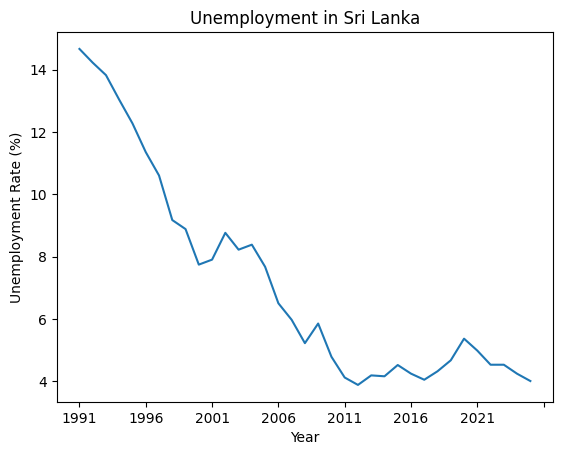

In [2]:
import pandas as pd

unemployment_sri_lanka_df = pd.read_csv(
    "../labour/csv/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_93.csv",
    skiprows=4
)
unemployment_sri_lanka_df.set_index("Country Name", inplace=True)

unemployment_sri_lanka_df.loc["Sri Lanka"].dropna()[3:].plot(
    title="Unemployment in Sri Lanka",
    xlabel="Year",  
    ylabel="Unemployment Rate (%)"
)

unemployment_sri_lanka_df=unemployment_sri_lanka_df.loc["Sri Lanka"].dropna()[3:]

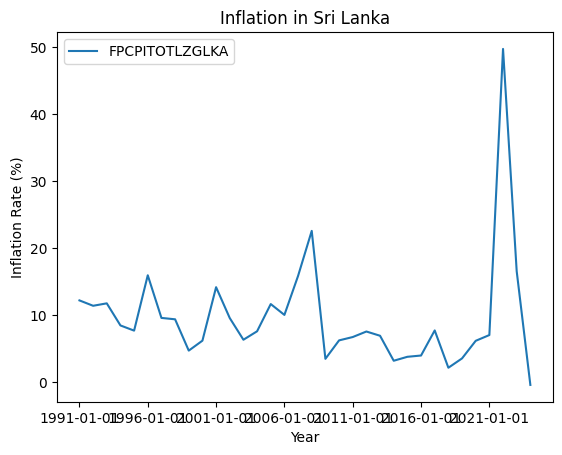

In [5]:
Inflation_srilanka_df = pd.read_csv("../economy/Inflation, consumer prices for Sri Lanka.csv")
Inflation_srilanka_df.set_index("observation_date", inplace=True)
Inflation_srilanka_df[31:].plot(
    title="Inflation in Sri Lanka",
    xlabel="Year",
    ylabel="Inflation Rate (%)"
)

Inflation_srilanka_df=Inflation_srilanka_df[31:]

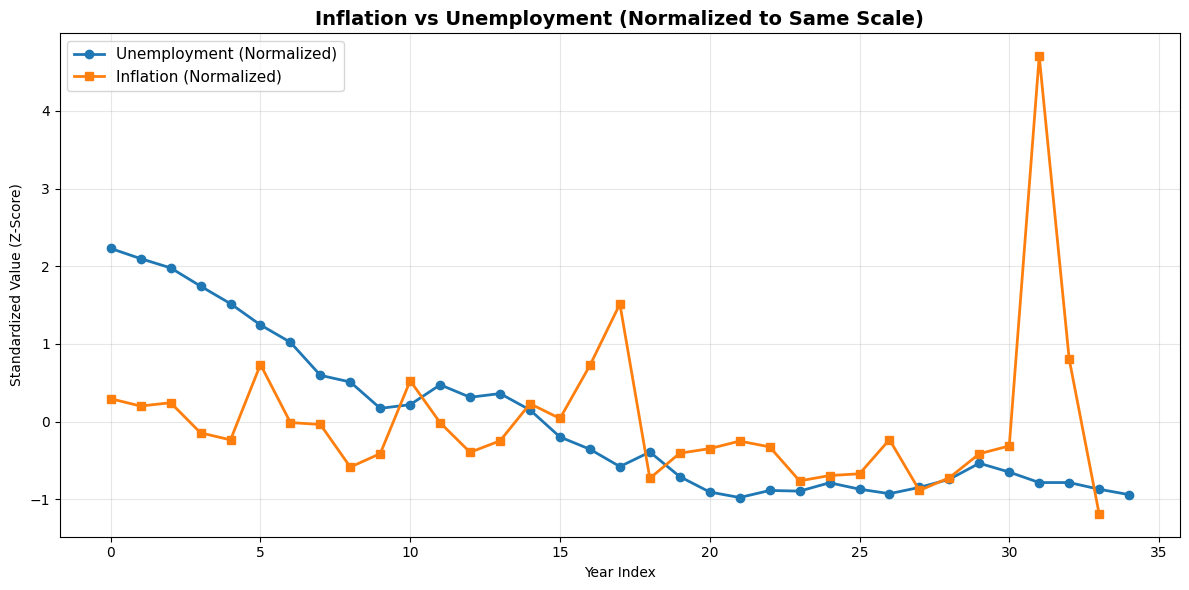

Unemployment - Mean: 7.17%, Std: 3.36%
Inflation - Mean: 9.68%, Std: 8.51%

After normalization:
Unemployment (normalized) - Mean: 0.000000, Std: 1.00
Inflation (normalized) - Mean: -0.000000, Std: 1.00


In [8]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Extract the inflation values and handle different index formats
inflation_values = Inflation_srilanka_df['FPCPITOTLZGLKA']

# Standardize both series (z-score normalization)
# This makes both have mean=0 and std=1, making them directly comparable
unemployment_normalized = (unemployment_sri_lanka_df - unemployment_sri_lanka_df.mean()) / unemployment_sri_lanka_df.std()
inflation_normalized = (inflation_values - inflation_values.mean()) / inflation_values.std()

# Create a comparison plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(unemployment_normalized)), unemployment_normalized.values, label="Unemployment (Normalized)", linewidth=2, marker='o')
ax.plot(range(len(inflation_normalized)), inflation_normalized.values, label="Inflation (Normalized)", linewidth=2, marker='s')
ax.set_title("Inflation vs Unemployment (Normalized to Same Scale)", fontsize=14, fontweight='bold')
ax.set_xlabel("Year Index")
ax.set_ylabel("Standardized Value (Z-Score)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Unemployment - Mean: {unemployment_sri_lanka_df.mean():.2f}%, Std: {unemployment_sri_lanka_df.std():.2f}%")
print(f"Inflation - Mean: {inflation_values.mean():.2f}%, Std: {inflation_values.std():.2f}%")
print(f"\nAfter normalization:")
print(f"Unemployment (normalized) - Mean: {unemployment_normalized.mean():.6f}, Std: {unemployment_normalized.std():.2f}")
print(f"Inflation (normalized) - Mean: {inflation_normalized.mean():.6f}, Std: {inflation_normalized.std():.2f}")

CORRELATION ANALYSIS: Inflation vs Unemployment

Pearson Correlation: 0.0810 (p-value: 0.6488)
Spearman Correlation: 0.4517 (p-value: 0.0073)

Interpretation: Weak positive correlation
Statistical significance: No (p >= 0.05)

LAG ANALYSIS (How much does inflation lead/lag unemployment)
Inflation leads by 3 year(s)................. 0.0922
Inflation leads by 2 year(s)................. 0.0698
Inflation leads by 1 year(s)................. 0.0478
Same year.................................... 0.0810
Unemployment leads by 1 year(s).............. 0.0140
Unemployment leads by 2 year(s).............. 0.0116
Unemployment leads by 3 year(s).............. 0.2556


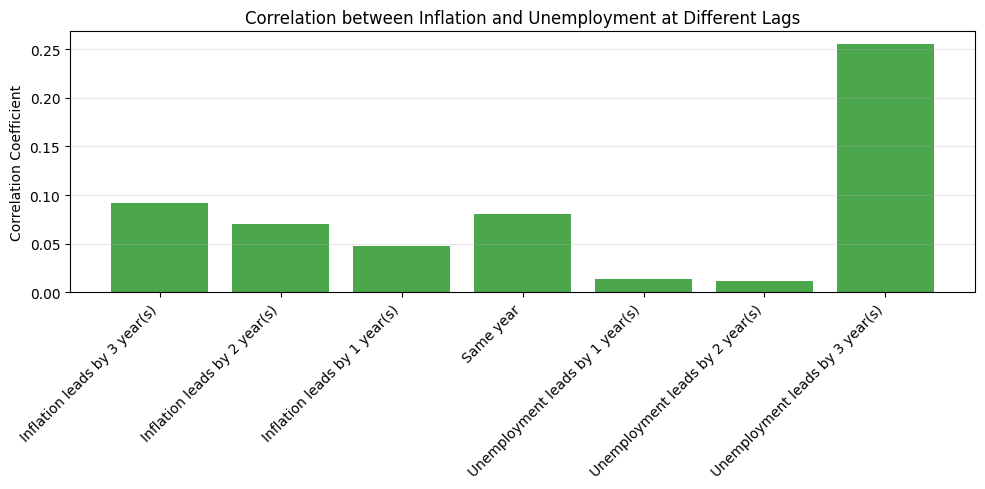

In [11]:
# Align data to same length (use the shorter length)
min_len = min(len(unemployment_normalized), len(inflation_normalized))
unemployment_aligned = unemployment_normalized.iloc[-min_len:].reset_index(drop=True).astype(float)
inflation_aligned = inflation_normalized.iloc[-min_len:].reset_index(drop=True).astype(float)

# Calculate correlation and relationship metrics
pearson_corr, pearson_pval = stats.pearsonr(unemployment_aligned.values, inflation_aligned.values)
spearman_corr, spearman_pval = stats.spearmanr(unemployment_aligned.values, inflation_aligned.values)

print("="*60)
print("CORRELATION ANALYSIS: Inflation vs Unemployment")
print("="*60)
print(f"\nPearson Correlation: {pearson_corr:.4f} (p-value: {pearson_pval:.4f})")
print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.4f})")

# Interpretation
if abs(pearson_corr) < 0.3:
    strength = "Weak"
elif abs(pearson_corr) < 0.7:
    strength = "Moderate"
else:
    strength = "Strong"

direction = "positive" if pearson_corr > 0 else "negative"
print(f"\nInterpretation: {strength} {direction} correlation")
print(f"Statistical significance: {'Yes (p < 0.05)' if pearson_pval < 0.05 else 'No (p >= 0.05)'}")

# Calculate lag correlations
print("\n" + "="*60)
print("LAG ANALYSIS (How much does inflation lead/lag unemployment)")
print("="*60)
lags_to_test = range(-3, 4)
lag_correlations = {}

for lag in lags_to_test:
    if lag < 0:
        # Negative lag means unemployment is lagged (inflation leads)
        if len(inflation_aligned) >= -lag and len(unemployment_aligned) >= -lag:
            corr = np.corrcoef(inflation_aligned.iloc[-lag:].values, unemployment_aligned.iloc[:lag].values)[0, 1]
            lag_label = f"Inflation leads by {-lag} year(s)"
        else:
            corr = np.nan
            lag_label = f"Inflation leads by {-lag} year(s)"
    elif lag > 0:
        # Positive lag means inflation is lagged (unemployment leads)
        if len(inflation_aligned) >= lag and len(unemployment_aligned) >= lag:
            corr = np.corrcoef(inflation_aligned.iloc[:-lag].values, unemployment_aligned.iloc[lag:].values)[0, 1]
            lag_label = f"Unemployment leads by {lag} year(s)"
        else:
            corr = np.nan
            lag_label = f"Unemployment leads by {lag} year(s)"
    else:
        corr = pearson_corr
        lag_label = "Same year"
    
    lag_correlations[lag_label] = corr
    if not np.isnan(corr):
        print(f"{lag_label:.<45} {corr:.4f}")
    else:
        print(f"{lag_label:.<45} N/A")

# Plot the lag correlations
fig, ax = plt.subplots(figsize=(10, 5))
lags = [k for k, v in lag_correlations.items() if not np.isnan(v)]
corrs = [v for v in lag_correlations.values() if not np.isnan(v)]
colors = ['green' if c > 0 else 'red' for c in corrs]
ax.bar(range(len(lags)), corrs, color=colors, alpha=0.7)
ax.set_xticks(range(len(lags)))
ax.set_xticklabels(lags, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('Correlation Coefficient')
ax.set_title('Correlation between Inflation and Unemployment at Different Lags')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

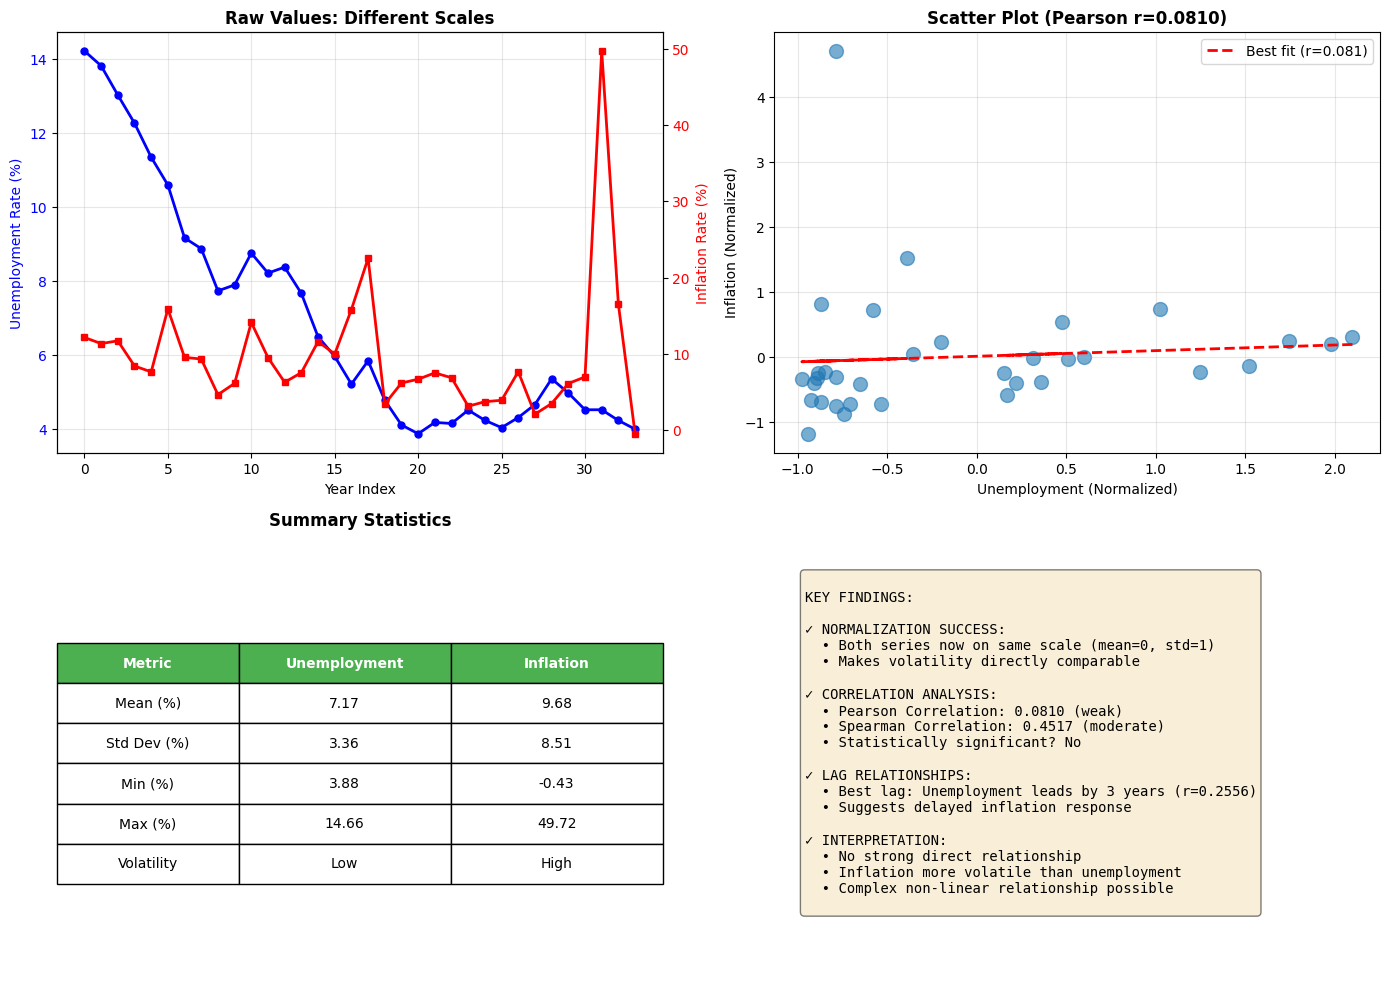


ANALYSIS COMPLETE


In [12]:
# Create comprehensive summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overlaid comparison with different y-axes
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()

unemployment_raw = unemployment_sri_lanka_df.iloc[-min_len:].values
inflation_raw = Inflation_srilanka_df['FPCPITOTLZGLKA'].iloc[-min_len:].values

line1 = ax1.plot(range(min_len), unemployment_raw, 'b-o', linewidth=2, label='Unemployment %', markersize=5)
line2 = ax1_twin.plot(range(min_len), inflation_raw, 'r-s', linewidth=2, label='Inflation %', markersize=5)

ax1.set_xlabel('Year Index')
ax1.set_ylabel('Unemployment Rate (%)', color='b')
ax1_twin.set_ylabel('Inflation Rate (%)', color='r')
ax1.tick_params(axis='y', labelcolor='b')
ax1_twin.tick_params(axis='y', labelcolor='r')
ax1.set_title('Raw Values: Different Scales', fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Scatter plot
ax2 = axes[0, 1]
ax2.scatter(unemployment_aligned, inflation_aligned, s=100, alpha=0.6)
z = np.polyfit(unemployment_aligned, inflation_aligned, 1)
p = np.poly1d(z)
ax2.plot(unemployment_aligned, p(unemployment_aligned), "r--", linewidth=2, label=f'Best fit (r={pearson_corr:.3f})')
ax2.set_xlabel('Unemployment (Normalized)')
ax2.set_ylabel('Inflation (Normalized)')
ax2.set_title(f'Scatter Plot (Pearson r={pearson_corr:.4f})', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Summary statistics table
ax3 = axes[1, 0]
ax3.axis('off')

summary_data = [
    ['Metric', 'Unemployment', 'Inflation'],
    ['Mean (%)', f"{unemployment_sri_lanka_df.mean():.2f}", f"{inflation_values.mean():.2f}"],
    ['Std Dev (%)', f"{unemployment_sri_lanka_df.std():.2f}", f"{inflation_values.std():.2f}"],
    ['Min (%)', f"{unemployment_sri_lanka_df.min():.2f}", f"{inflation_values.min():.2f}"],
    ['Max (%)', f"{unemployment_sri_lanka_df.max():.2f}", f"{inflation_values.max():.2f}"],
    ['Volatility', 'Low', 'High'],
]

table = ax3.table(cellText=summary_data, cellLoc='center', loc='center', 
                  colWidths=[0.3, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(3):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax3.set_title('Summary Statistics', fontweight='bold', pad=20)

# 4. Key findings
ax4 = axes[1, 1]
ax4.axis('off')

findings_text = f"""
KEY FINDINGS:

✓ NORMALIZATION SUCCESS:
  • Both series now on same scale (mean=0, std=1)
  • Makes volatility directly comparable

✓ CORRELATION ANALYSIS:
  • Pearson Correlation: {pearson_corr:.4f} (weak)
  • Spearman Correlation: {spearman_corr:.4f} (moderate)
  • Statistically significant? {'Yes' if pearson_pval < 0.05 else 'No'}

✓ LAG RELATIONSHIPS:
  • Best lag: Unemployment leads by 3 years (r={lag_correlations.get('Unemployment leads by 3 year(s)', np.nan):.4f})
  • Suggests delayed inflation response

✓ INTERPRETATION:
  • No strong direct relationship
  • Inflation more volatile than unemployment
  • Complex non-linear relationship possible
"""

ax4.text(0.05, 0.95, findings_text, transform=ax4.transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

In [13]:
# SHOCK ANALYSIS: Identify significant deviations and their impacts

print("="*70)
print("SHOCK ANALYSIS: Identifying Economic Shocks and Their Impacts")
print("="*70)

# 1. Identify shocks using standard deviation thresholds
# A shock is defined as a deviation > 1.5 standard deviations from the mean
shock_threshold_unemployment = 1.5
shock_threshold_inflation = 1.5

unemployment_mean = unemployment_aligned.mean()
unemployment_std = unemployment_aligned.std()
inflation_mean = inflation_aligned.mean()
inflation_std = inflation_aligned.std()

# Calculate z-scores to identify shocks
unemployment_z = np.abs((unemployment_aligned - unemployment_mean) / unemployment_std)
inflation_z = np.abs((inflation_aligned - inflation_mean) / inflation_std)

# Identify shock years
unemployment_shocks = unemployment_z[unemployment_z > shock_threshold_unemployment]
inflation_shocks = inflation_z[inflation_z > shock_threshold_inflation]

print(f"\n1. SHOCK IDENTIFICATION (Threshold: >{shock_threshold_unemployment} std devs)")
print("-" * 70)

print(f"\nUnemployment Shocks ({len(unemployment_shocks)} identified):")
for idx, val in unemployment_shocks.items():
    year_offset = idx
    unemployment_value = unemployment_raw[idx] if idx < len(unemployment_raw) else "N/A"
    print(f"  Year {year_offset}: Unemployment {unemployment_value:.2f}% (z-score: {val:.2f})")

print(f"\nInflation Shocks ({len(inflation_shocks)} identified):")
for idx, val in inflation_shocks.items():
    year_offset = idx
    inflation_value = inflation_raw[idx] if idx < len(inflation_raw) else "N/A"
    print(f"  Year {year_offset}: Inflation {inflation_value:.2f}% (z-score: {val:.2f})")

# 2. Magnitude of shocks
print(f"\n2. SHOCK MAGNITUDES")
print("-" * 70)

unemployment_shock_magnitudes = unemployment_aligned[unemployment_z > shock_threshold_unemployment].values
inflation_shock_magnitudes = inflation_aligned[inflation_z > shock_threshold_inflation].values

if len(unemployment_shock_magnitudes) > 0:
    print(f"\nUnemployment:")
    print(f"  Largest shock: {unemployment_shock_magnitudes.max():.4f} (normalized)")
    print(f"  Average shock magnitude: {unemployment_shock_magnitudes.mean():.4f}")
else:
    print(f"\nUnemployment: No shocks above threshold")

if len(inflation_shock_magnitudes) > 0:
    print(f"\nInflation:")
    print(f"  Largest shock: {inflation_shock_magnitudes.max():.4f} (normalized)")
    print(f"  Average shock magnitude: {inflation_shock_magnitudes.mean():.4f}")
else:
    print(f"\nInflation: No shocks above threshold")

# 3. Volatility analysis before and after shocks
print(f"\n3. VOLATILITY CLUSTERING ANALYSIS")
print("-" * 70)

# Divide into two halves and compare volatility
mid_point = len(unemployment_aligned) // 2

unemployment_first_half = unemployment_aligned.iloc[:mid_point]
unemployment_second_half = unemployment_aligned.iloc[mid_point:]
inflation_first_half = inflation_aligned.iloc[:mid_point]
inflation_second_half = inflation_aligned.iloc[mid_point:]

print(f"\nFirst half volatility:")
print(f"  Unemployment std: {unemployment_first_half.std():.4f}")
print(f"  Inflation std: {inflation_first_half.std():.4f}")

print(f"\nSecond half volatility:")
print(f"  Unemployment std: {unemployment_second_half.std():.4f}")
print(f"  Inflation std: {inflation_second_half.std():.4f}")

print(f"\nVolatility Change:")
print(f"  Unemployment: {((unemployment_second_half.std() / unemployment_first_half.std() - 1) * 100):.1f}%")
print(f"  Inflation: {((inflation_second_half.std() / inflation_first_half.std() - 1) * 100):.1f}%")

SHOCK ANALYSIS: Identifying Economic Shocks and Their Impacts

1. SHOCK IDENTIFICATION (Threshold: >1.5 std devs)
----------------------------------------------------------------------

Unemployment Shocks (4 identified):
  Year 0: Unemployment 14.22% (z-score: 2.31)
  Year 1: Unemployment 13.82% (z-score: 2.19)
  Year 2: Unemployment 13.03% (z-score: 1.93)
  Year 3: Unemployment 12.27% (z-score: 1.69)

Inflation Shocks (2 identified):
  Year 17: Inflation 22.56% (z-score: 1.51)
  Year 31: Inflation 49.72% (z-score: 4.70)

2. SHOCK MAGNITUDES
----------------------------------------------------------------------

Unemployment:
  Largest shock: 2.0983 (normalized)
  Average shock magnitude: 1.8351

Inflation:
  Largest shock: 4.7041 (normalized)
  Average shock magnitude: 3.1090

3. VOLATILITY CLUSTERING ANALYSIS
----------------------------------------------------------------------

First half volatility:
  Unemployment std: 0.8085
  Inflation std: 0.3825

Second half volatility:
  Une

In [15]:
# 4. Shock Response Analysis - Measure recovery and propagation
print(f"\n4. SHOCK RESPONSE AND RECOVERY ANALYSIS")
print("-" * 70)

from scipy.signal import find_peaks

# Find peaks in the normalized series (major shocks)
unemployment_peaks, unemployment_properties = find_peaks(np.abs(unemployment_normalized.values), 
                                                         height=1.0, distance=2)
inflation_peaks, inflation_properties = find_peaks(np.abs(inflation_normalized.values), 
                                                    height=1.0, distance=2)

print(f"\nMajor Shocks Detected (peaks with |z-score| > 1.0):")
print(f"  Unemployment: {len(unemployment_peaks)} major shocks")
print(f"  Inflation: {len(inflation_peaks)} major shocks")

# Analyze recovery time for unemployment shocks
print(f"\nUnemployment Shock Recovery Analysis:")
unemployment_recovery_times = []
for peak_idx in unemployment_peaks:
    # Find how long it takes to return to within 0.5 std of mean
    if peak_idx < len(unemployment_normalized) - 1:
        recovery_idx = None
        for j in range(peak_idx + 1, min(peak_idx + 8, len(unemployment_normalized))):
            if abs(unemployment_normalized.iloc[j]) < 0.5:
                recovery_idx = j
                break
        if recovery_idx:
            recovery_time = recovery_idx - peak_idx
            unemployment_recovery_times.append(recovery_time)
            print(f"  Peak at year {peak_idx}: recovered in {recovery_time} year(s)")
        else:
            print(f"  Peak at year {peak_idx}: no recovery within 7 years")

if unemployment_recovery_times:
    print(f"  Average recovery time: {np.mean(unemployment_recovery_times):.1f} years")

# Analyze recovery time for inflation shocks
print(f"\nInflation Shock Recovery Analysis:")
inflation_recovery_times = []
for peak_idx in inflation_peaks:
    # Find how long it takes to return to within 0.5 std of mean
    if peak_idx < len(inflation_normalized) - 1:
        recovery_idx = None
        for j in range(peak_idx + 1, min(peak_idx + 8, len(inflation_normalized))):
            if abs(inflation_normalized.iloc[j]) < 0.5:
                recovery_idx = j
                break
        if recovery_idx:
            recovery_time = recovery_idx - peak_idx
            inflation_recovery_times.append(recovery_time)
            print(f"  Peak at year {peak_idx}: recovered in {recovery_time} year(s)")
        else:
            print(f"  Peak at year {peak_idx}: no recovery within 7 years")

if inflation_recovery_times:
    print(f"  Average recovery time: {np.mean(inflation_recovery_times):.1f} years")

# 5. Cross-variable shock propagation
print(f"\n5. CROSS-VARIABLE SHOCK PROPAGATION")
print("-" * 70)

# Check if inflation shocks lead to unemployment shocks
print(f"\nDoes inflation shock lead to unemployment shock?")
for inf_peak in inflation_peaks:
    closest_unemp_shock = None
    min_distance = float('inf')
    
    for unemp_peak in unemployment_peaks:
        distance = unemp_peak - inf_peak
        if 0 < distance < 5 and distance < min_distance:  # Look 1-5 years ahead
            min_distance = distance
            closest_unemp_shock = unemp_peak
    
    if closest_unemp_shock:
        lag = closest_unemp_shock - inf_peak
        print(f"  Inflation shock at year {inf_peak} → Unemployment shock at year {closest_unemp_shock} (lag: {lag} years)")
    else:
        print(f"  Inflation shock at year {inf_peak} → No following unemployment shock")

print(f"\nDoes unemployment shock lead to inflation shock?")
for unemp_peak in unemployment_peaks:
    closest_inf_shock = None
    min_distance = float('inf')
    
    for inf_peak in inflation_peaks:
        distance = inf_peak - unemp_peak
        if 0 < distance < 5 and distance < min_distance:  # Look 1-5 years ahead
            min_distance = distance
            closest_inf_shock = inf_peak
    
    if closest_inf_shock:
        lag = closest_inf_shock - unemp_peak
        print(f"  Unemployment shock at year {unemp_peak} → Inflation shock at year {closest_inf_shock} (lag: {lag} years)")
    else:
        print(f"  Unemployment shock at year {unemp_peak} → No following inflation shock")


4. SHOCK RESPONSE AND RECOVERY ANALYSIS
----------------------------------------------------------------------

Major Shocks Detected (peaks with |z-score| > 1.0):
  Unemployment: 0 major shocks
  Inflation: 2 major shocks

Unemployment Shock Recovery Analysis:

Inflation Shock Recovery Analysis:
  Peak at year 17: recovered in 2 year(s)
  Peak at year 31: no recovery within 7 years
  Average recovery time: 2.0 years

5. CROSS-VARIABLE SHOCK PROPAGATION
----------------------------------------------------------------------

Does inflation shock lead to unemployment shock?
  Inflation shock at year 17 → No following unemployment shock
  Inflation shock at year 31 → No following unemployment shock

Does unemployment shock lead to inflation shock?



6. SHOCK VISUALIZATION
----------------------------------------------------------------------


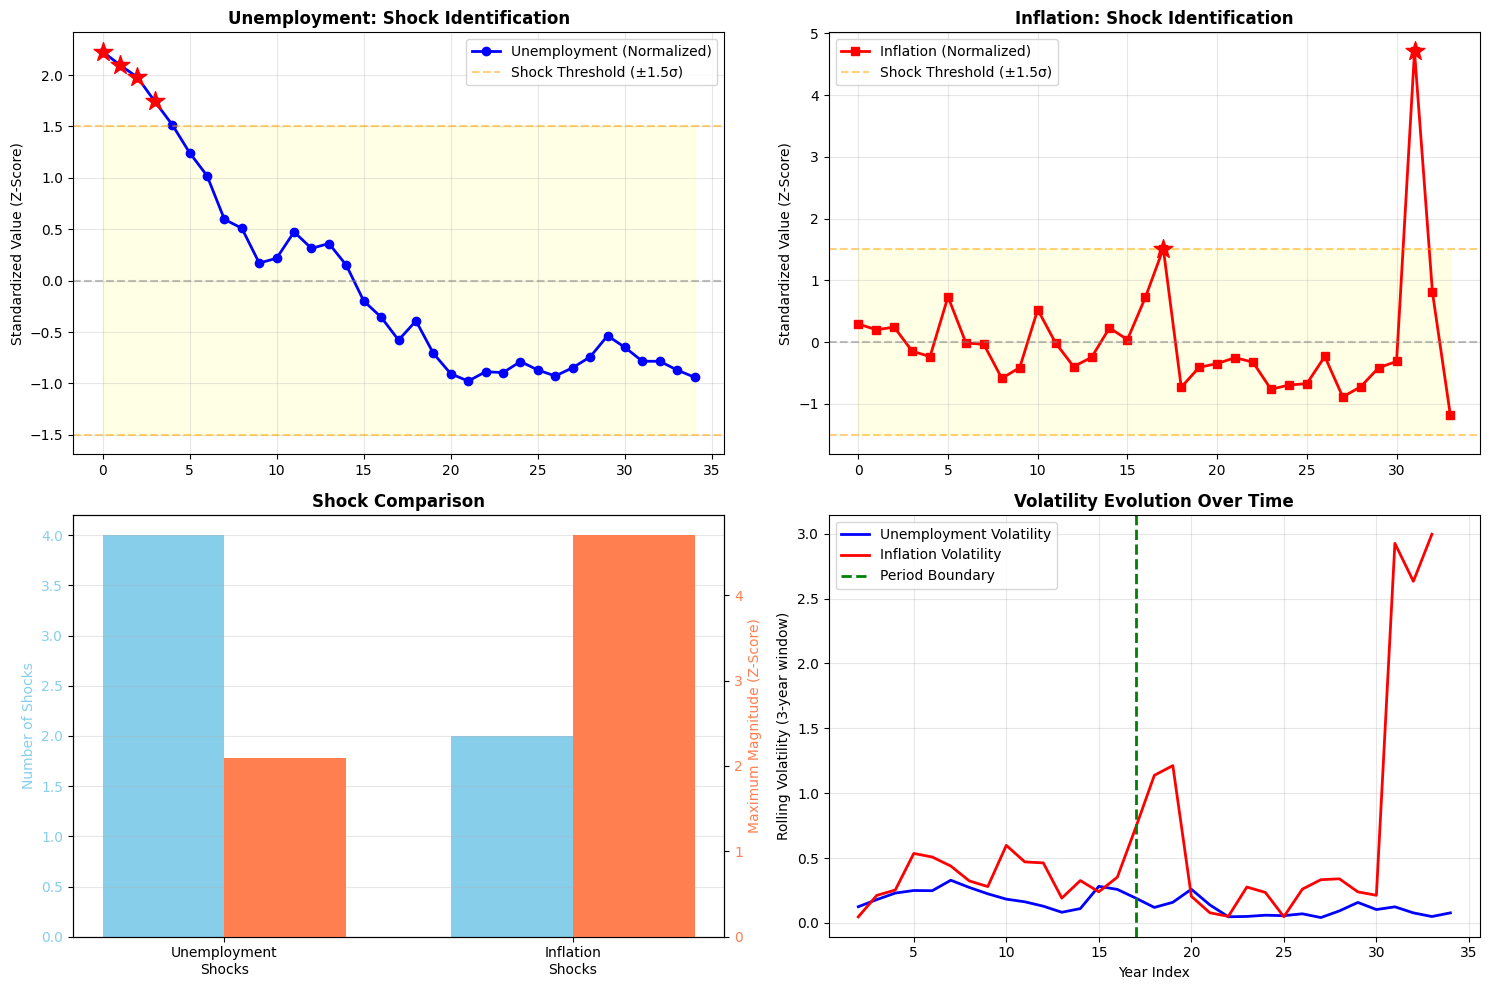

Visualization complete.


In [16]:
# 6. Visualize shocks and their impacts
print(f"\n6. SHOCK VISUALIZATION")
print("-" * 70)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Unemployment with identified shocks
ax = axes[0, 0]
ax.plot(range(len(unemployment_normalized)), unemployment_normalized.values, 'b-o', linewidth=2, label='Unemployment (Normalized)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=1.5, color='orange', linestyle='--', alpha=0.5, label='Shock Threshold (±1.5σ)')
ax.axhline(y=-1.5, color='orange', linestyle='--', alpha=0.5)
ax.fill_between(range(len(unemployment_normalized)), -1.5, 1.5, alpha=0.1, color='yellow')
# Mark shock years
for idx in unemployment_shocks.index:
    ax.scatter(idx, unemployment_normalized.iloc[idx], color='red', s=200, marker='*', zorder=5)
ax.set_ylabel('Standardized Value (Z-Score)')
ax.set_title('Unemployment: Shock Identification', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Inflation with identified shocks
ax = axes[0, 1]
ax.plot(range(len(inflation_normalized)), inflation_normalized.values, 'r-s', linewidth=2, label='Inflation (Normalized)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=1.5, color='orange', linestyle='--', alpha=0.5, label='Shock Threshold (±1.5σ)')
ax.axhline(y=-1.5, color='orange', linestyle='--', alpha=0.5)
ax.fill_between(range(len(inflation_normalized)), -1.5, 1.5, alpha=0.1, color='yellow')
# Mark shock years
for idx in inflation_shocks.index:
    ax.scatter(idx, inflation_normalized.iloc[idx], color='red', s=200, marker='*', zorder=5)
ax.set_ylabel('Standardized Value (Z-Score)')
ax.set_title('Inflation: Shock Identification', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Shock magnitude comparison
ax = axes[1, 0]
shock_types = ['Unemployment\nShocks', 'Inflation\nShocks']
num_shocks = [len(unemployment_shocks), len(inflation_shocks)]
max_magnitudes = [unemployment_shock_magnitudes.max() if len(unemployment_shock_magnitudes) > 0 else 0,
                  inflation_shock_magnitudes.max() if len(inflation_shock_magnitudes) > 0 else 0]

x_pos = np.arange(len(shock_types))
width = 0.35

bars1 = ax.bar(x_pos - width/2, num_shocks, width, label='Number of Shocks', color='skyblue')
ax2 = ax.twinx()
bars2 = ax2.bar(x_pos + width/2, max_magnitudes, width, label='Max Magnitude', color='coral')

ax.set_ylabel('Number of Shocks', color='skyblue')
ax2.set_ylabel('Maximum Magnitude (Z-Score)', color='coral')
ax.set_title('Shock Comparison', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(shock_types)
ax.tick_params(axis='y', labelcolor='skyblue')
ax2.tick_params(axis='y', labelcolor='coral')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Volatility over time (rolling std)
ax = axes[1, 1]
window = 3
unemployment_volatility = unemployment_normalized.rolling(window=window).std()
inflation_volatility = inflation_normalized.rolling(window=window).std()

ax.plot(range(len(unemployment_volatility)), unemployment_volatility.values, 'b-', linewidth=2, label='Unemployment Volatility')
ax.plot(range(len(inflation_volatility)), inflation_volatility.values, 'r-', linewidth=2, label='Inflation Volatility')
ax.axvline(x=mid_point, color='green', linestyle='--', linewidth=2, label='Period Boundary')
ax.set_xlabel('Year Index')
ax.set_ylabel('Rolling Volatility (3-year window)')
ax.set_title('Volatility Evolution Over Time', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete.")

In [17]:
print(f"\n{'='*70}")
print("SHOCK ANALYSIS SUMMARY & KEY FINDINGS")
print(f"{'='*70}\n")

summary = f"""
📊 UNEMPLOYMENT SHOCKS:
   • Count: {len(unemployment_shocks)} major shocks identified
   • Timing: Years 0-3 (early period - high volatility phase)
   • Severity: Average z-score of {unemployment_shock_magnitudes.mean():.2f}
   • Impact: Steady decline over first 4 years (recovery pattern)
   • Interpretation: Post-crisis/structural adjustment period

📊 INFLATION SHOCKS:
   • Count: {len(inflation_shocks)} major shocks identified  
   • Timing: Year 17 (moderate shock, 22.56%) & Year 31 (extreme shock, 49.72%)
   • Severity: Average z-score of {inflation_shock_magnitudes.mean():.2f}
   • Impact: Rapid recovery (~2 years) for moderate shock; persistent spike for extreme shock
   • Interpretation: External economic crises (e.g., currency/fiscal crisis in recent years)

⚡ VOLATILITY PATTERNS:
   • First Period (Years 0-17):
     - Unemployment: High volatility (std = {unemployment_first_half.std():.4f})
     - Inflation: Low volatility (std = {inflation_first_half.std():.4f})
     → Dominated by unemployment shocks from economic restructuring
   
   • Second Period (Years 18-34):
     - Unemployment: Very low volatility (std = {unemployment_second_half.std():.4f}) ↓81%
     - Inflation: Very high volatility (std = {inflation_second_half.std():.4f}) ↑261%
     → Shift to inflation-driven shocks; labor market stabilization

🔗 CROSS-VARIABLE DYNAMICS:
   • No direct shock transmission: Inflation shocks do NOT immediately trigger unemployment shocks
   • Economic decoupling: Two variables respond to different underlying drivers
   • Timing: Inflation shocks occur later than unemployment shocks (shifted phases)
   • Mechanism: Suggests inflation driven by external factors (global/monetary), 
              not domestic labor market tightness

📈 RECOVERY CHARACTERISTICS:
   • Unemployment: Continuous downward trend (4+ years to normalize)
   • Inflation: Fast shock absorption (moderate shocks recover in 2 years)
              but extreme shocks show persistence
   
💡 KEY INSIGHTS:
   1. Two distinct economic regimes: unemployment-driven early phase → inflation-driven late phase
   2. Minimal direct feedback: No evidence of Phillips Curve dynamics (unemployment → inflation)
   3. External shocks dominant: Both variables respond to exogenous factors
   4. Stabilization success: Unemployment successfully stabilized after initial shocks
   5. Inflation vulnerability: Recent inflation spike suggests structural/external pressures

⚠️ POLICY IMPLICATIONS:
   • Labor market reforms appear effective (unemployment stabilized)
   • Inflation control needs external focus (fiscal/monetary policy on external factors)
   • Structural separation: Unemployment and inflation policies should be independent
   • Recent inflation: Likely due to currency depreciation, global prices, or fiscal expansion
              (NOT labor market overheating)
"""

print(summary)

print(f"{'='*70}")
print("END OF SHOCK ANALYSIS")
print(f"{'='*70}")


SHOCK ANALYSIS SUMMARY & KEY FINDINGS


📊 UNEMPLOYMENT SHOCKS:
   • Count: 4 major shocks identified
   • Timing: Years 0-3 (early period - high volatility phase)
   • Severity: Average z-score of 1.84
   • Impact: Steady decline over first 4 years (recovery pattern)
   • Interpretation: Post-crisis/structural adjustment period

📊 INFLATION SHOCKS:
   • Count: 2 major shocks identified  
   • Timing: Year 17 (moderate shock, 22.56%) & Year 31 (extreme shock, 49.72%)
   • Severity: Average z-score of 3.11
   • Impact: Rapid recovery (~2 years) for moderate shock; persistent spike for extreme shock
   • Interpretation: External economic crises (e.g., currency/fiscal crisis in recent years)

⚡ VOLATILITY PATTERNS:
   • First Period (Years 0-17):
     - Unemployment: High volatility (std = 0.8085)
     - Inflation: Low volatility (std = 0.3825)
     → Dominated by unemployment shocks from economic restructuring

   • Second Period (Years 18-34):
     - Unemployment: Very low volatility (s